# Smart Meters

This example uses the following datasets to predict peoples' electricity consumption. You can download the Jupyter Notebook of the study <a href="smart_meters.ipynb">here</a>. We'll use the following datasets:

<a href="../../data/smart_meters/sm_consumption.csv">sm_consumption</a>
<ul class="ul_content">
    <li><b>dateUTC: </b>Date and time of the record</li>
    <li><b>meterID: </b>Smart meter ID</li>
    <li><b>value: </b>Electricity consumed during 30 minute interval (in kWh)</li>
</ul>

<a href="../../data/smart_meters/sm_weather.csv">sm_weather</a>
<ul class="ul_content">
    <li><b>dateUTC: </b>Date and time of the record</li>
    <li><b>temperature: </b>Temperature</li>
    <li><b>humidity: </b>Humidity</li>
</ul>

<a href="../../data/smart_meters/sm_meters.csv">sm_meters</a>
<ul class="ul_content">
    <li><b>longitude: </b>Longitude</li>
    <li><b>latitude: </b>Latitude</li>
    <li><b>residenceType: </b>1 for Single-Family; 2 for Multi-Family; 3 for Appartement</li>
</ul>

We will follow the data science cycle (Data Exploration - Data Preparation - Data Modeling - Model Evaluation - Model Deployment) to solve this problem.

## Initialization

This example uses the following version of VerticaPy:

In [1]:
import verticapy as vp
vp.__version__

/usr/local/lib/python3.12/site-packages/vertica_highcharts/highcharts/highcharts.py:11: UserWarning: future library does not support Python 3.12 yet. The import is skipped.
  warnings.warn('future library does not support Python 3.12 yet. The import is skipped.')
/usr/local/lib/python3.12/site-packages/vertica_highcharts/highmaps/highmaps.py:11: UserWarning: future library does not support Python 3.12 yet. The import is skipped.
  warnings.warn('future library does not support Python 3.12 yet. The import is skipped.')
/usr/local/lib/python3.12/site-packages/vertica_highcharts/highstock/highstock.py:11: UserWarning: future library does not support Python 3.12 yet. The import is skipped.
  warnings.warn('future library does not support Python 3.12 yet. The import is skipped.')


'1.0.1'

Connect to Vertica. This example uses an existing connection called "VerticaDSN." For details on how to create a connection, use see the <a href="https://www.vertica.com/python/documentation/1.0.x/html/connection.html">connection tutorial</a>.

You can skip the below cell if you already have an established connection.

In [2]:
vp.connect("VerticaDSN")

Create the vDataFrames of the datasets:

,123meterIDInteger,📅dateUTCTimestamp(29),123valueNumeric(12)
1,0,2014-01-01 11:00:00,0.029
2,0,2014-01-01 13:45:00,0.277
3,0,2014-01-02 10:45:00,0.321
4,0,2014-01-02 11:15:00,0.305
5,0,2014-01-02 13:45:00,0.358
6,0,2014-01-02 15:30:00,0.115
7,0,2014-01-03 08:30:00,0.071
8,0,2014-01-04 23:45:00,0.323
9,0,2014-01-06 01:15:00,0.085
10,0,2014-01-06 21:45:00,0.713

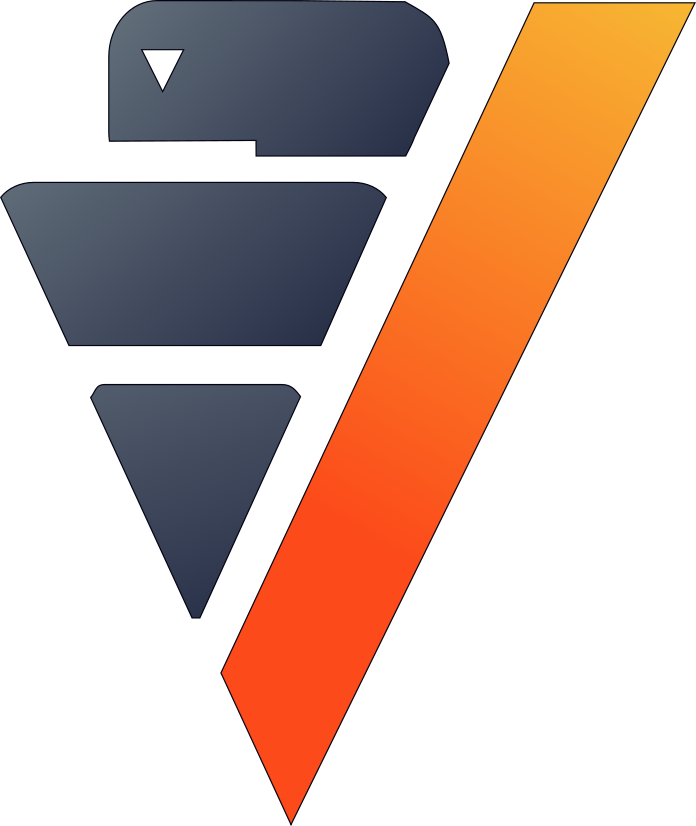

,📅dateUTCTimestamp(29),123temperatureNumeric(12),123humidityNumeric(13)
1,2014-01-01 00:00:00,38.0,95.0
2,2014-01-01 00:30:00,37.4,93.0
3,2014-01-01 01:00:00,37.4,100.0
4,2014-01-01 01:30:00,37.4,100.0
5,2014-01-01 02:00:00,39.2,93.0
6,2014-01-01 02:30:00,39.2,93.0
7,2014-01-01 03:00:00,39.2,93.0
8,2014-01-01 03:30:00,39.2,93.0
9,2014-01-01 04:00:00,39.2,93.0
10,2014-01-01 04:30:00,39.2,93.0

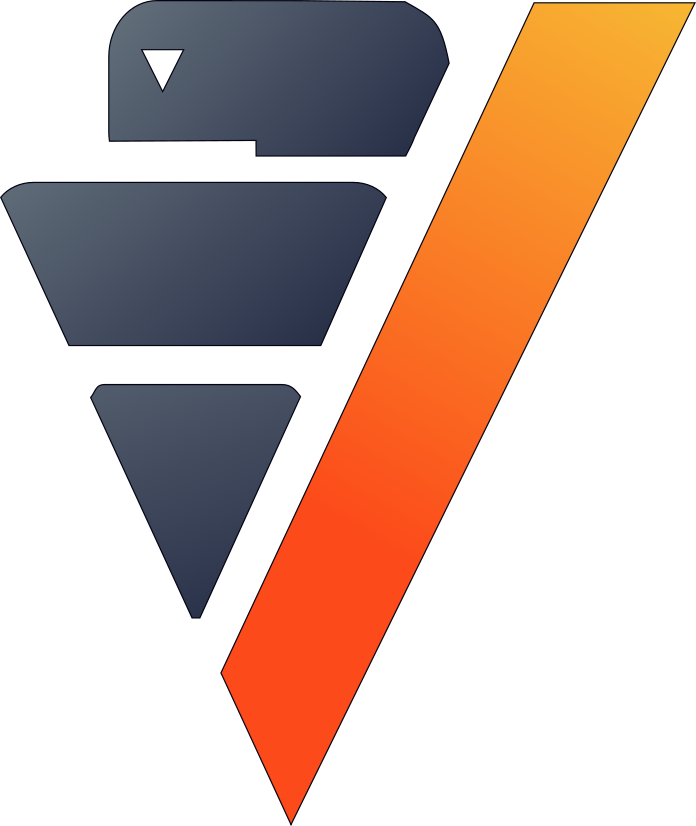

,123meterIDInteger,123residenceTypeInteger,🌎latitudeFloat(22),🌎longitudeFloat(22)
1,0,1,53.3575915882838,-6.27554509198069
2,1,1,53.3130886440828,-6.21174062227953
3,2,1,53.322863954253,-6.25885396251447
4,3,3,51.895226209818,-8.54531304761961
5,4,1,53.6511753623331,-6.69348712237822
6,5,1,53.3262233045899,-6.31623713317817
7,6,3,53.3816401612885,-6.24222877491921
8,7,3,53.4410265504271,-6.2749868845315
9,8,1,53.2883538726462,-6.31547263281076
10,9,1,53.307294775666,-6.171585396401

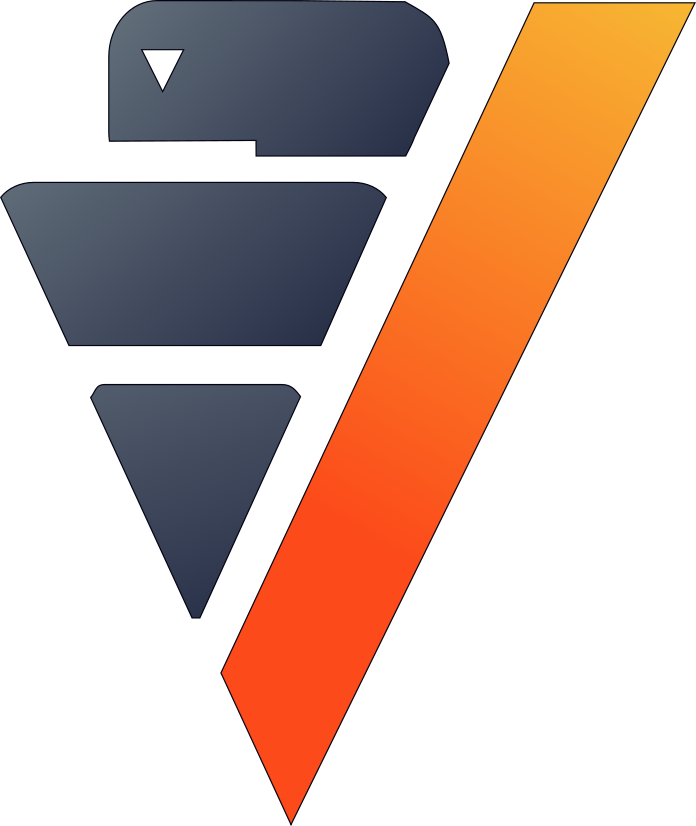

In [3]:
sm_consumption = vp.read_csv("sm_consumption.csv")
sm_weather = vp.read_csv("sm_weather.csv")
sm_meters = vp.read_csv("sm_meters.csv")
display(sm_consumption)
display(sm_weather)
display(sm_meters)

## Data Exploration and Preparation

Predicting energy consumption in households is very important. Surges in electricity use could cause serious power outages. In our case, we'll be using data on general household energy consumption in Ireland to predict consumption at various times.

In order to join the different data sources, we need to assume that the weather will be approximately the same across the entirety of Ireland. We'll use the date and time as the key to join 'sm_weather' and 'sm_consumption'.

<b>Joining different datasets with interpolation</b>

In VerticaPy, you can interpolate joins; Vertica will find the closest timestamp to the key and join the result.

,📅dateUTCTimestamp(29),123meterIDInteger,123valueNumeric(12),123humidityNumeric(13),123temperatureNumeric(12)
1,2014-01-01 00:00:00,913,0.097,95.0,38.0
2,2014-01-01 00:00:00,895,0.184,95.0,38.0
3,2014-01-01 00:00:00,795,0.093,95.0,38.0
4,2014-01-01 00:00:00,780,0.116,95.0,38.0
5,2014-01-01 00:00:00,747,0.559,95.0,38.0
6,2014-01-01 00:00:00,660,0.836,95.0,38.0
7,2014-01-01 00:00:00,640,1.796,95.0,38.0
8,2014-01-01 00:00:00,605,0.038,95.0,38.0
9,2014-01-01 00:00:00,484,0.211,95.0,38.0
10,2014-01-01 00:00:00,474,0.313,95.0,38.0

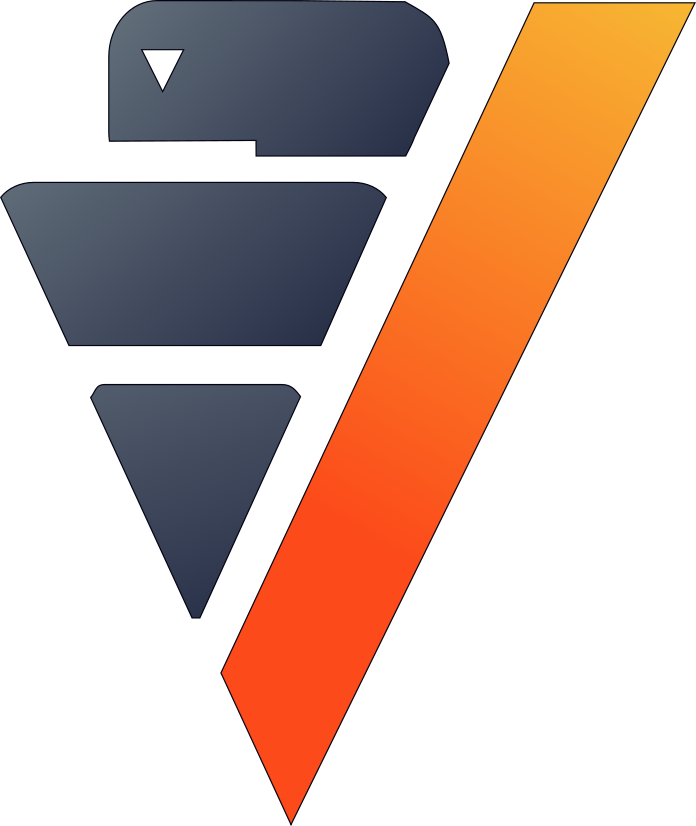

In [4]:
sm_consumption_weather = sm_consumption.join(
                            sm_weather,
                            how = "left",
                            on_interpolate = {"dateUTC": "dateUTC"},
                            expr1 = ["dateUTC", "meterID", "value"],
                            expr2 = ["humidity", "temperature"])
display(sm_consumption_weather)

<b>Segmenting Latitude & Longitude using Clustering</b>

The dataset 'sm_meters' is pretty important. In particular, the type of residence is probably a good predictor for electricity usage. We can create clusters of the different regions with k-means clustering based on longitude and latitude. Let's find the most suitable 'k' using an elbow curve and scatter plot.

Note: To create the geo plot, you will need to install the geopandas library.

,min,max
"""meterID""",0.0,999.0
"""residenceType""",1.0,3.0
"""latitude""",51.7964600770212,54.0270361317983
"""longitude""",-9.16352332036362,-6.07134572494937

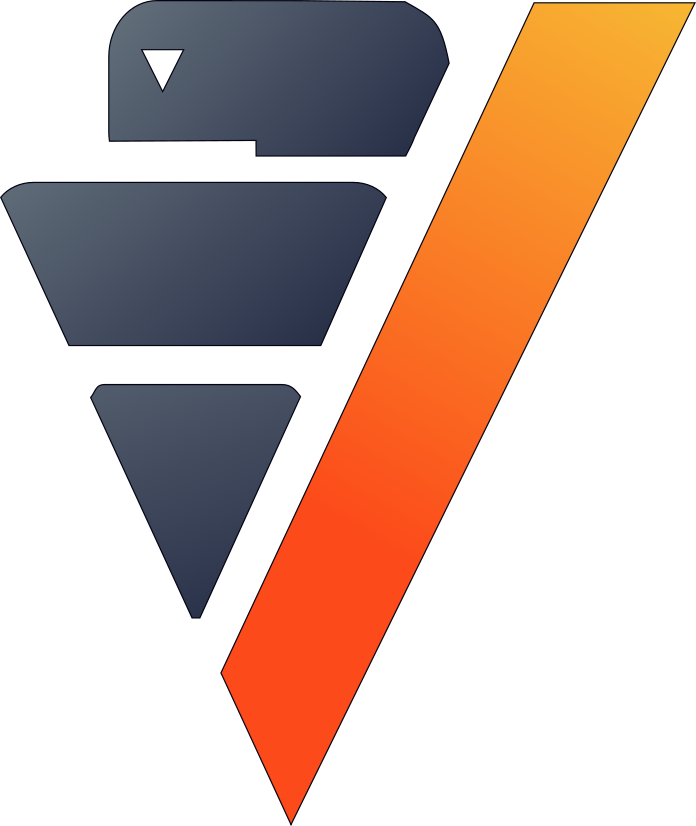

In [5]:
sm_meters.agg(["min", "max"])

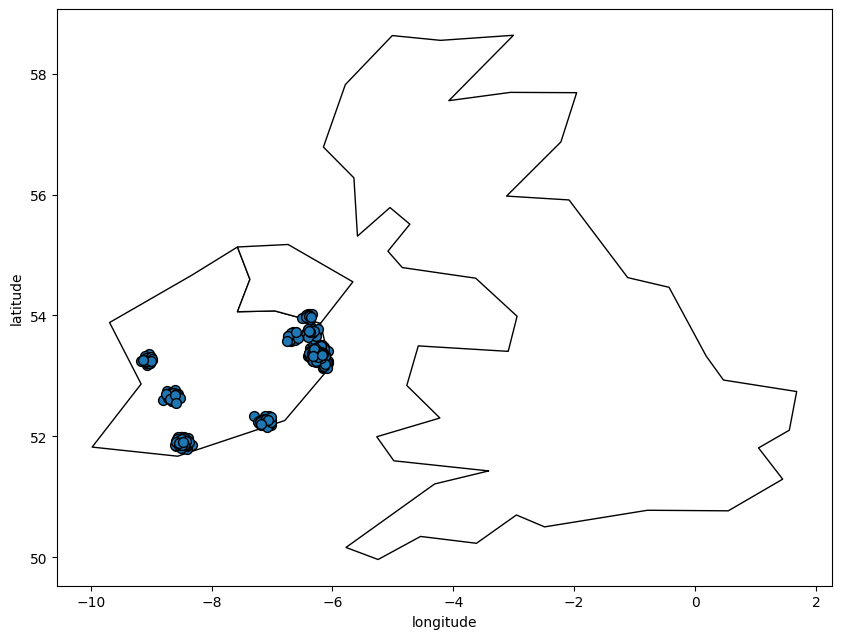

In [6]:
from verticapy.machine_learning.model_selection import elbow
from verticapy.datasets import load_world

# Change plotting library to matplotlib
vp.set_option("plotting_lib", "matplotlib")

world = load_world()
df = world.to_geopandas(geometry = "geometry")
df = df[df["country"].isin(["Ireland", "United Kingdom"])]
ax = df.plot(edgecolor = "black",
             color = "white",
             figsize = (10, 9))
ax = sm_meters.scatter(["longitude", "latitude"], ax = ax)

Based on the scatter plot, five seems like the optimal number of clusters. Let's verify this hypothesis using an elbow curve.

  0%|          | 0/5 [00:00<?, ?it/s]

<Axes: title={'center': 'Elbow Curve'}, xlabel='Number of Clusters', ylabel='Elbow Score (Between-Cluster SS / Total SS)'>

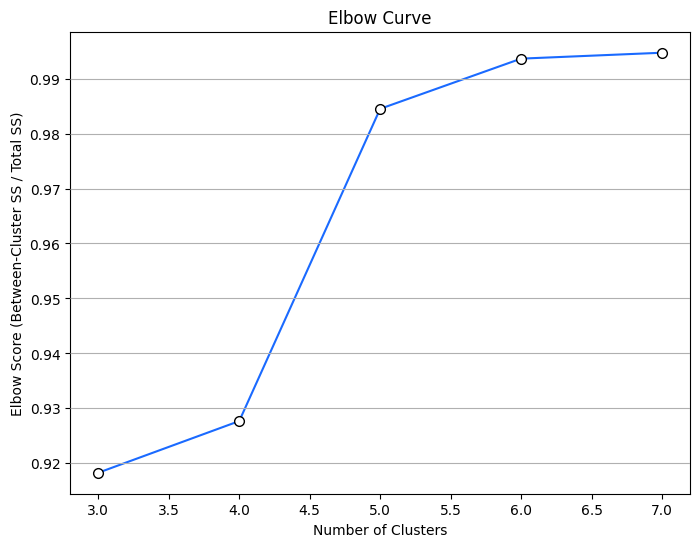

In [7]:
elbow(sm_meters, ["longitude", "latitude"], n_cluster = (3, 8))

The elbow curve seems to confirm that five is the optimal number of clusters, so let's create a k-means model with that in mind.

In [8]:
from verticapy.machine_learning.vertica.cluster import KMeans
model = KMeans("kmeans_sm_regions", 
               n_cluster = 5,
               init = [(-6.26980, 53.38127),
                       (-9.06178, 53.25998),
                       (-8.48641, 51.90216),
                       (-7.12408, 52.24610),
                       (-8.63985, 52.65945),])
model.drop()
model.fit(sm_meters, 
          ["longitude", "latitude"])



centers
longitude|latitude
---------+--------
-9.06178 |53.25998
-8.63985 |52.65945
-8.48641 |51.90216
-7.12408 |52.24610
-6.26980 |53.38127


metrics
Evaluation metrics:
     Total Sum of Squares: 1209.2077
     Within-Cluster Sum of Squares: 
         Cluster 0: 0.099754154
         Cluster 1: 0.2779225
         Cluster 2: 0.53464463
         Cluster 3: 0.2657853
         Cluster 4: 17.892423
     Total Within-Cluster Sum of Squares: 19.07053
     Between-Cluster Sum of Squares: 1190.1372
     Between-Cluster SS / Total SS: 98.42%
 Number of iterations performed: 1
 Converged: True
 Call:
kmeans('public.kmeans_sm_regions', '"public"."_verticapy_tmp_view_v_demo_05c87052c0ff11ee8de90242ac120003_"', '"longitude", "latitude"', 5
USING PARAMETERS max_iterations=300, epsilon=0.0001, initial_centers_table='"public"."_verticapy_tmp_kmeans_init_v_demo_05c92e0cc0ff11ee8de90242ac120003_"', distance_method='euclidean')


Let's add our clusters to the vDataFrame.

In [9]:
sm_meters = model.predict(sm_meters, name = "region")

Let's draw a scatter plot of the different regions.

<Axes: xlabel='longitude', ylabel='latitude'>

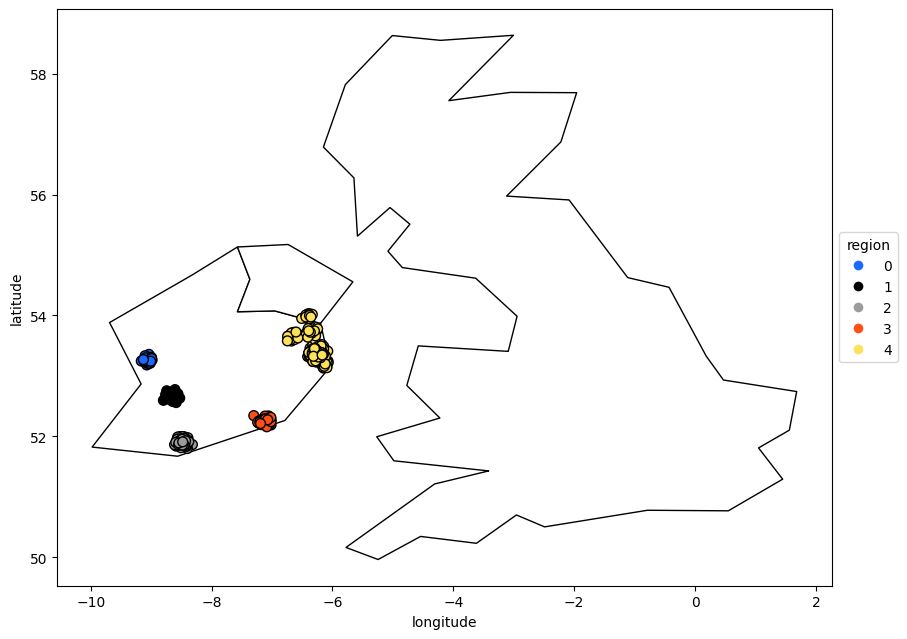

In [10]:
ax = df.plot(edgecolor = "black",
             color = "white",
             figsize = (10, 9))
sm_meters.scatter(["longitude", "latitude"], 
                  by = "region",
                  max_cardinality = 10,
                  ax = ax)

<b>Dataset Enrichment</b>

Let's join 'sm_meters' with 'sm_consumption_weather'.

,📅dateUTCTimestamp(29),123meterIDInteger,123valueNumeric(12),123humidityNumeric(13),123temperatureNumeric(12),123residenceTypeInteger,123regionInteger
1,2014-01-01 00:00:00,913,0.097,95.0,38.0,3,4
2,2014-01-01 00:00:00,895,0.184,95.0,38.0,1,4
3,2014-01-01 00:00:00,795,0.093,95.0,38.0,1,4
4,2014-01-01 00:00:00,780,0.116,95.0,38.0,1,4
5,2014-01-01 00:00:00,747,0.559,95.0,38.0,2,4
6,2014-01-01 00:00:00,660,0.836,95.0,38.0,1,4
7,2014-01-01 00:00:00,640,1.796,95.0,38.0,1,1
8,2014-01-01 00:00:00,605,0.038,95.0,38.0,3,1
9,2014-01-01 00:00:00,484,0.211,95.0,38.0,1,4
10,2014-01-01 00:00:00,474,0.313,95.0,38.0,2,2

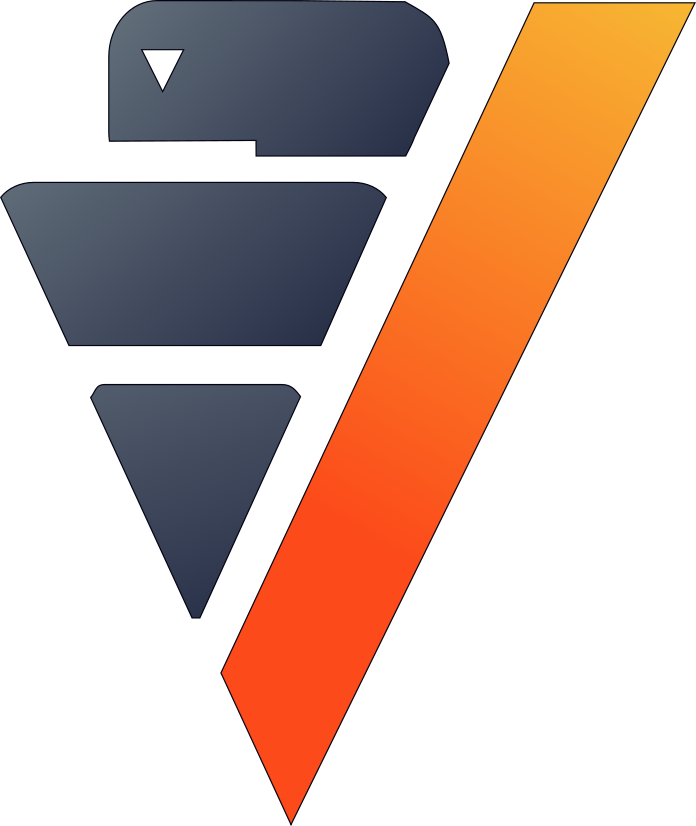

In [11]:
sm_consumption_weather_region = sm_consumption_weather.join(
                                    sm_meters,
                                    how = "natural",
                                    expr1 = ["*"],
                                    expr2 = ["residenceType", 
                                             "region"])
display(sm_consumption_weather_region)

<b>Handling Missing Values</b>

Let's take care of our missing values.

,count,percent
"""dateUTC""",1188432.0,100.0
"""meterID""",1188432.0,100.0
"""humidity""",1188432.0,100.0
"""temperature""",1188432.0,100.0
"""residenceType""",1188432.0,100.0
"""region""",1188432.0,100.0
"""value""",1188412.0,99.998

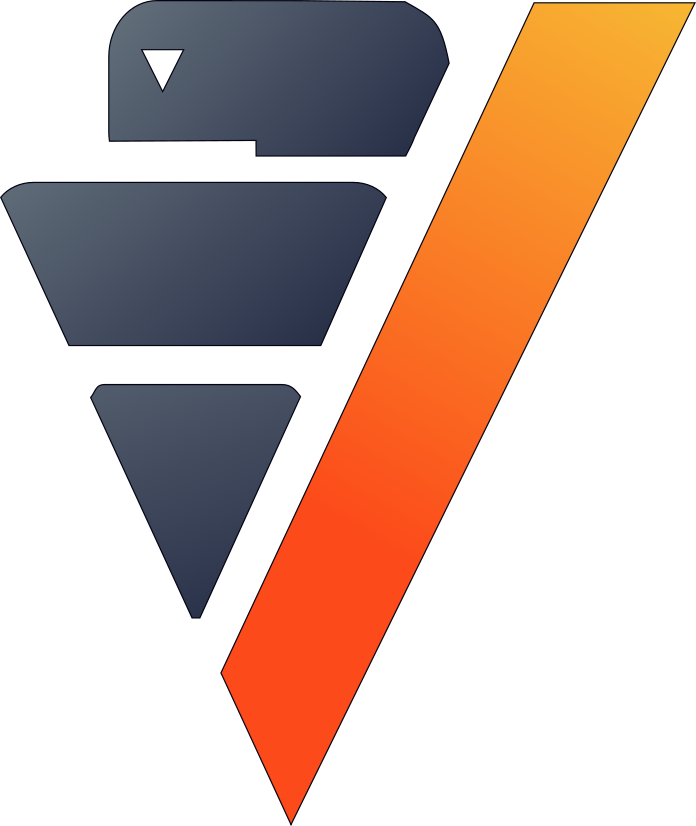

In [12]:
sm_consumption_weather_region.count_percent()

The variable 'value' has a few missing values that we can drop.

20 elements were filtered.


,count
"""dateUTC""",1188412.0
"""meterID""",1188412.0
"""value""",1188412.0
"""humidity""",1188412.0
"""temperature""",1188412.0
"""residenceType""",1188412.0
"""region""",1188412.0

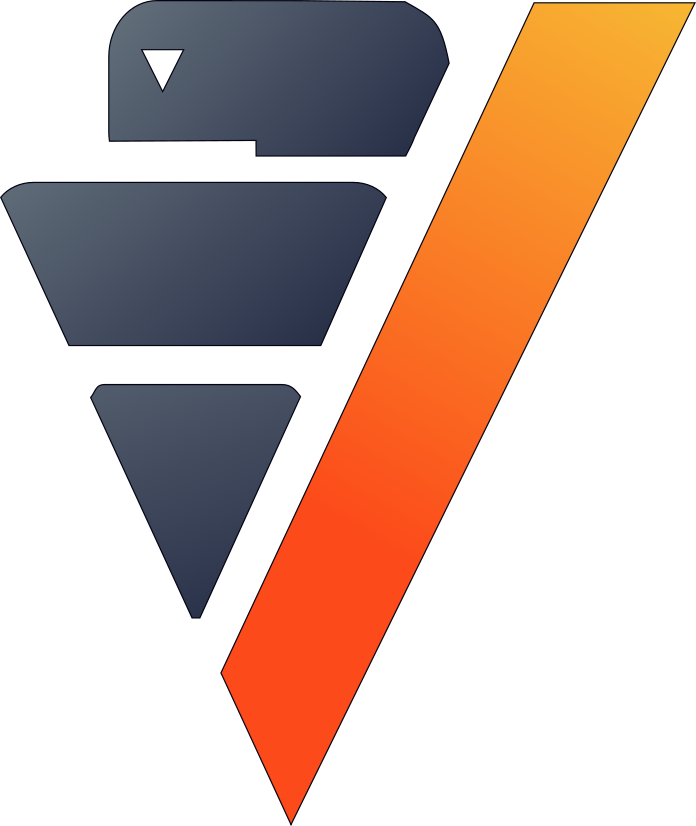

In [13]:
sm_consumption_weather_region["value"].dropna()
sm_consumption_weather_region.count()

<b>Interpolation & Aggregations</b>

Since power outages seem relatively common in each area, and the "value" represents the electricity consumed during 30 minute intervals (in kWh),  it'd be a good idea to interpolate and aggregate the data to get a monthly average in electricity consumption per region.

Let's save our new dataset in the Vertica database.

In [14]:
vp.drop("sm_consumption_weather_region", method = "table")
sm_consumption_weather_region.to_db("sm_consumption_weather_region",
                                    relation_type = "table")
sm_consumption_weather_region_clean = vp.vDataFrame("sm_consumption_weather_region")

To get an equally-sliced dataset, we can then interpolate to fill any gaps. This operation is essential for creating correct time series models.

,📅dateUTCTimestamp(29),123meterIDInteger,123valueFloat(22),123humidityFloat(22),123temperatureFloat(22),123residenceTypeInteger,123regionInteger
1,2014-01-01 07:00:00,9,[null],[null],[null],[null],[null]
2,2014-01-01 07:30:00,9,2.24324242424242,92.8181818181818,37.4545454545455,1,4
3,2014-01-01 08:00:00,9,2.11772727272727,92.4545454545455,37.5636363636364,1,4
4,2014-01-01 08:30:00,9,1.99221212121212,92.0909090909091,37.6727272727273,1,4
5,2014-01-01 09:00:00,9,1.86669696969697,91.7272727272727,37.7818181818182,1,4
6,2014-01-01 09:30:00,9,1.74118181818182,91.3636363636364,37.8909090909091,1,4
7,2014-01-01 10:00:00,9,1.61566666666667,91.0,38.0,1,4
8,2014-01-01 10:30:00,9,1.49015151515152,90.6363636363636,38.1090909090909,1,4
9,2014-01-01 11:00:00,9,1.36463636363636,90.2727272727273,38.2181818181818,1,4
10,2014-01-01 11:30:00,9,1.23912121212121,89.9090909090909,38.3272727272727,1,4

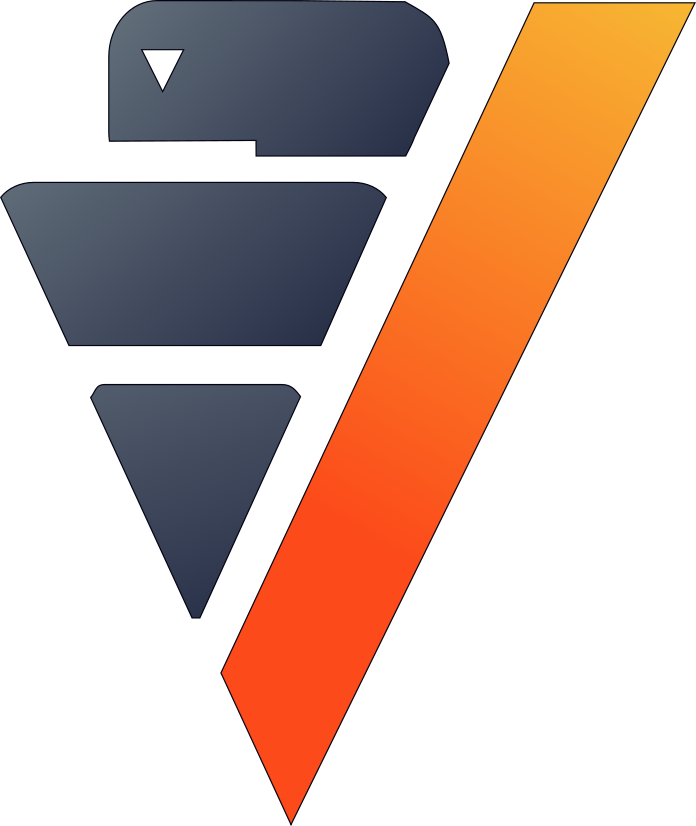

In [15]:
sm_consumption_weather_region_clean = sm_consumption_weather_region_clean.interpolate(
                                                                        ts = "dateUTC",
                                                                        rule = "30 minutes",
                                                                        method = {"value": "linear",
                                                                                  "humidity": "linear",
                                                                                  "temperature": "linear",
                                                                                  "residenceType": "ffill",
                                                                                  "region": "ffill"},
                                                                        by = ["meterID"])
display(sm_consumption_weather_region_clean)

Let's aggregate the data to figure out the monthly energy consumption for each smart meter. We can then save the result in the Vertica database.

476563 elements were filtered.
462 elements were filtered.


,123meterIDInteger,123regionInteger,123residenceTypeInteger,📅dateUTCTimestamp(29),123monthInteger,📅date_monthTimestamp(29),123valueFloat(22),123avg_temperatureFloat(22),123avg_humidityFloat(22)
1,395,1,3,2014-12-18 22:00:00,12,2014-12-01 00:00:00,0.149472,35.2688,82.344
2,395,1,3,2014-12-18 22:30:00,12,2014-12-01 00:00:00,0.153216,35.3264,82.632
3,395,1,3,2014-12-18 23:00:00,12,2014-12-01 00:00:00,0.15696,35.384,82.92
4,395,1,3,2014-12-18 23:30:00,12,2014-12-01 00:00:00,0.160704,35.4416,83.208
5,395,1,3,2014-12-19 00:00:00,12,2014-12-01 00:00:00,0.164448,35.4992,83.496
6,395,1,3,2014-12-19 00:30:00,12,2014-12-01 00:00:00,0.168192,35.5568,83.784
7,395,1,3,2014-12-19 01:00:00,12,2014-12-01 00:00:00,0.171936,35.6144,84.072
8,395,1,3,2014-12-19 01:30:00,12,2014-12-01 00:00:00,0.17568,35.672,84.36
9,395,1,3,2014-12-19 02:00:00,12,2014-12-01 00:00:00,0.179424,35.7296,84.648
10,395,1,3,2014-12-19 02:30:00,12,2014-12-01 00:00:00,0.183168,35.7872,84.936

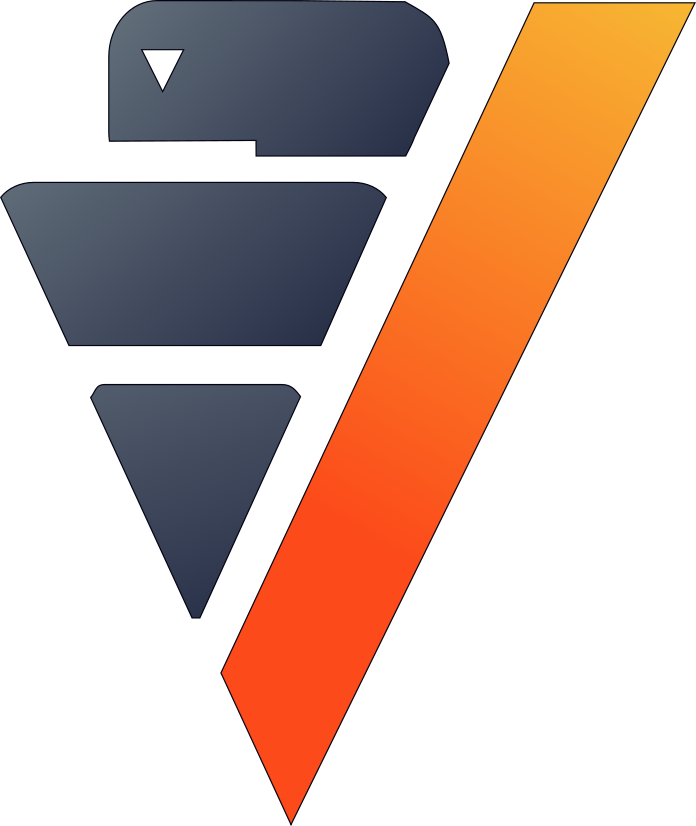

In [16]:
import verticapy.sql.functions as st
sm_consumption_month = sm_consumption_weather_region_clean.groupby(
                    columns = ["meterID",
                               "region", 
                               "residenceType",
                               "dateUTC",
                              ],
                    expr = ["MONTH(dateUTC) AS month",
                            "DATE_TRUNC('MONTH', dateUTC::date) AS date_month",
                            st.sum(sm_consumption_weather_region["value"])._as("value"),
                            st.avg(sm_consumption_weather_region["temperature"])._as("avg_temperature"),
                            st.avg(sm_consumption_weather_region["humidity"])._as("avg_humidity")]).filter(
                                                                                    "date_month < '2015-09-01'")
sm_consumption_month.dropna(["value"])
vp.drop("sm_consumption_month", method = "table")
sm_consumption_month.to_db("sm_consumption_month",
                           relation_type = "table",
                           inplace = True)

<b>Understanding the Data & Detecting Outliers</b>

Looking at three different smart meters, we can see a clear decrease in energy consumption during the summer followed by a sharp increase in the winter.

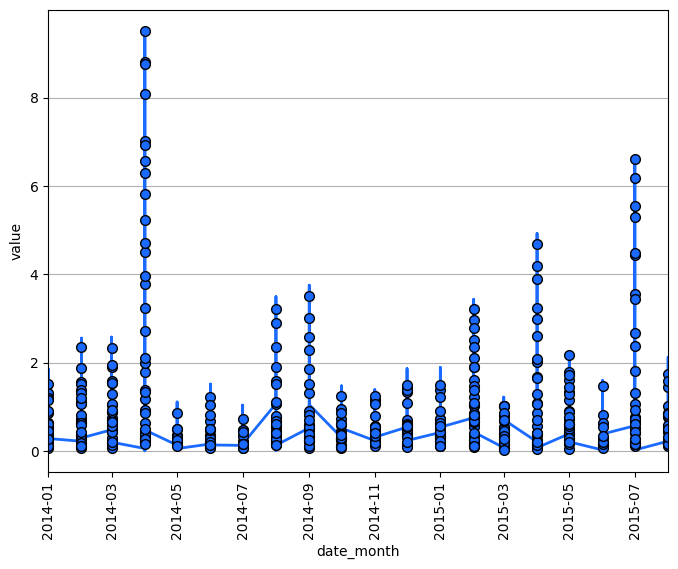

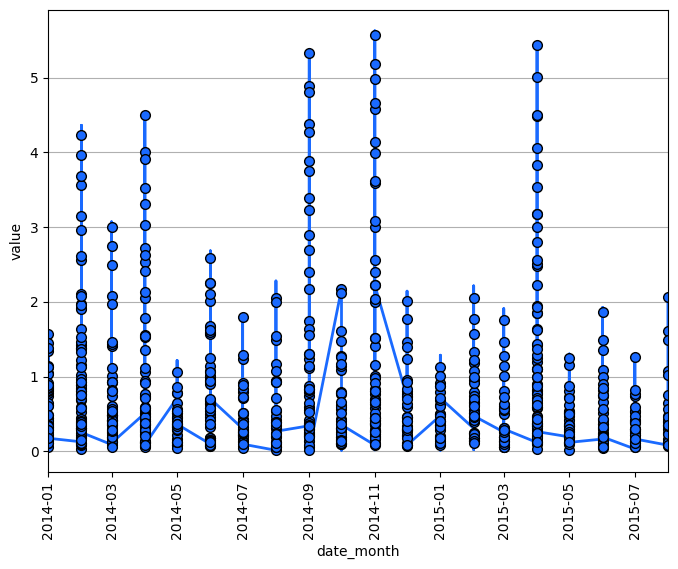

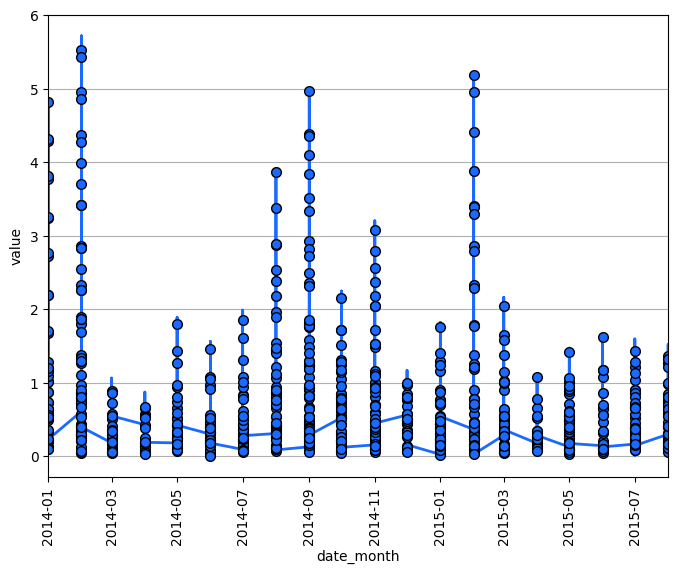

In [17]:
for i in [10, 12, 14]:
    sm_consumption_month[sm_consumption_month["meterID"] == i]["value"].plot(ts = "date_month")

This behavior seems to be seasonal, but we don't have enough data to prove this.

Let's find outliers in the distribution by computing the ZSCORE per meterID.

,123meterIDInteger,123regionInteger,123residenceTypeInteger,📅dateUTCTimestamp(29),123monthInteger,📅date_monthTimestamp(29),123valueFloat(22),123avg_temperatureFloat(22),123avg_humidityFloat(22),123value_zscoreFloat(22)
1,0,4,1,2014-01-10 11:30:00,1,2014-01-01 00:00:00,3.65733333333333,45.2,72.6666666666667,5.32512370744387
2,0,4,1,2014-01-10 12:00:00,1,2014-01-01 00:00:00,4.85311111111111,45.4,73.2222222222222,7.24861446396984
3,0,4,1,2014-01-10 12:30:00,1,2014-01-01 00:00:00,6.04888888888889,45.6,73.7777777777778,9.17210522049581
4,0,4,1,2014-01-10 13:00:00,1,2014-01-01 00:00:00,7.24466666666667,45.8,74.3333333333333,11.0955959770218
5,0,4,1,2014-01-10 13:30:00,1,2014-01-01 00:00:00,8.44044444444445,46.0,74.8888888888889,13.0190867335478
6,0,4,1,2014-01-10 14:00:00,1,2014-01-01 00:00:00,9.63622222222222,46.2,75.4444444444444,14.9425774900737
7,0,4,1,2014-01-10 14:30:00,1,2014-01-01 00:00:00,10.832,46.4,76.0,16.8660682465997
8,0,4,1,2014-01-10 15:00:00,1,2014-01-01 00:00:00,7.06,46.4,73.5,10.7985469492067
9,0,4,1,2014-01-10 15:30:00,1,2014-01-01 00:00:00,3.288,46.4,71.0,4.73102565181366
10,0,4,1,2014-01-19 08:30:00,1,2014-01-01 00:00:00,3.27145945945946,36.3405405405405,90.8918918918919,4.70441905531309

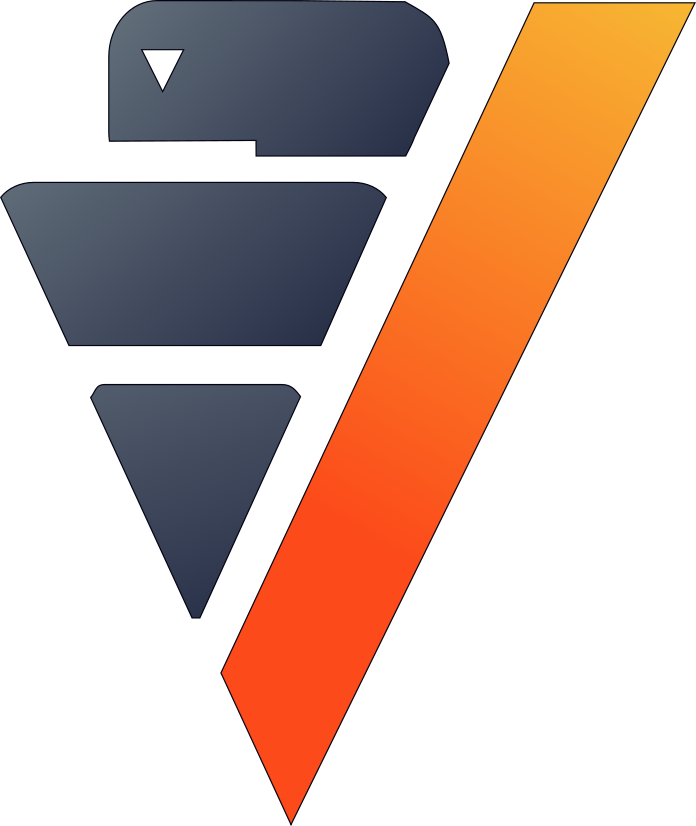

In [18]:
std = st.std(sm_consumption_month["value"])._over(by = [sm_consumption_month["meterID"]])
avg = st.avg(sm_consumption_month["value"])._over(by = [sm_consumption_month["meterID"]])
sm_consumption_month["value_zscore"] = (sm_consumption_month["value"] - avg) / std
sm_consumption_month.search("value_zscore > 4")

Four smart meters are outliers in energy consumption. We'll need to investigate to get more information.

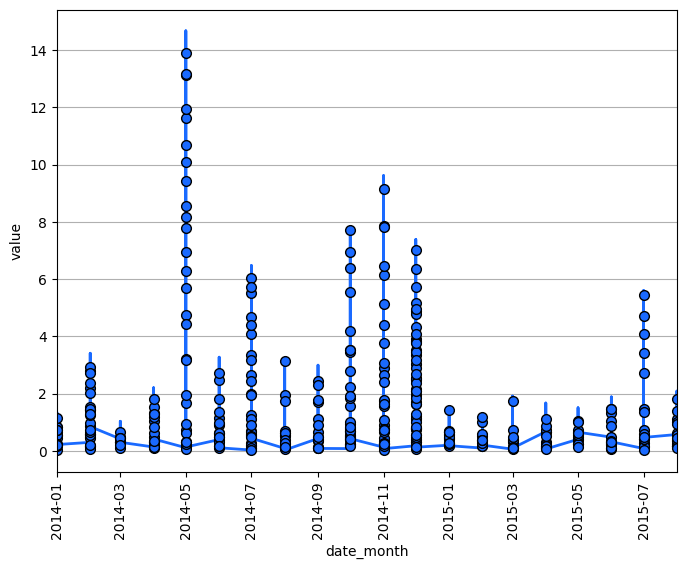

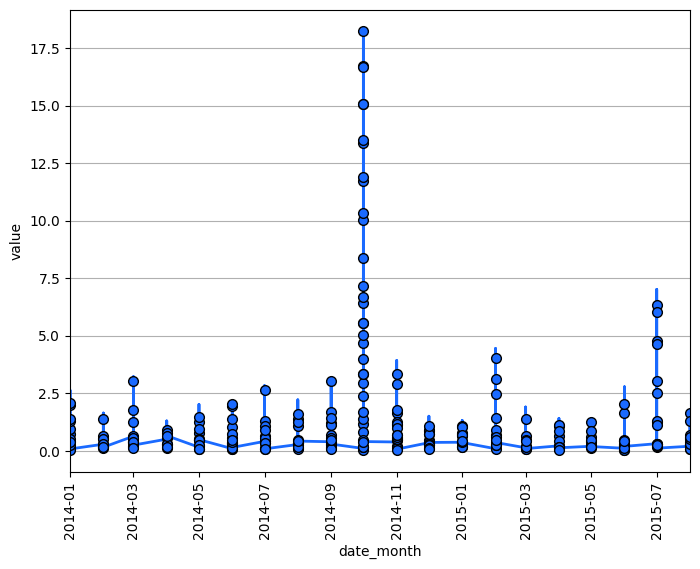

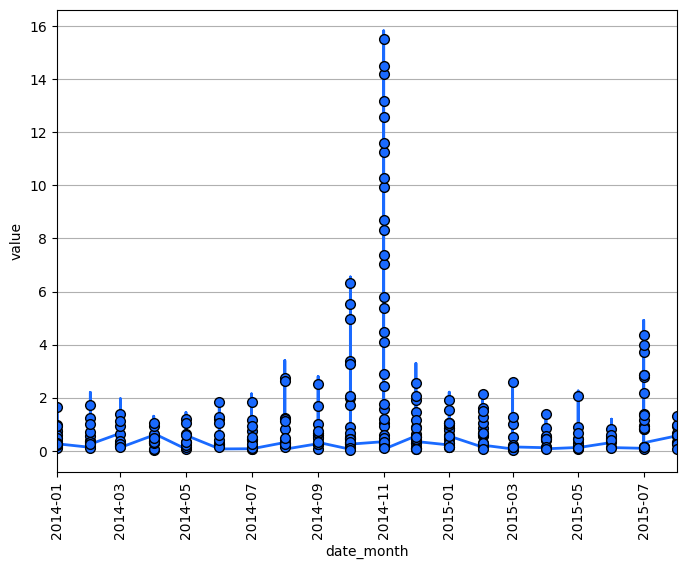

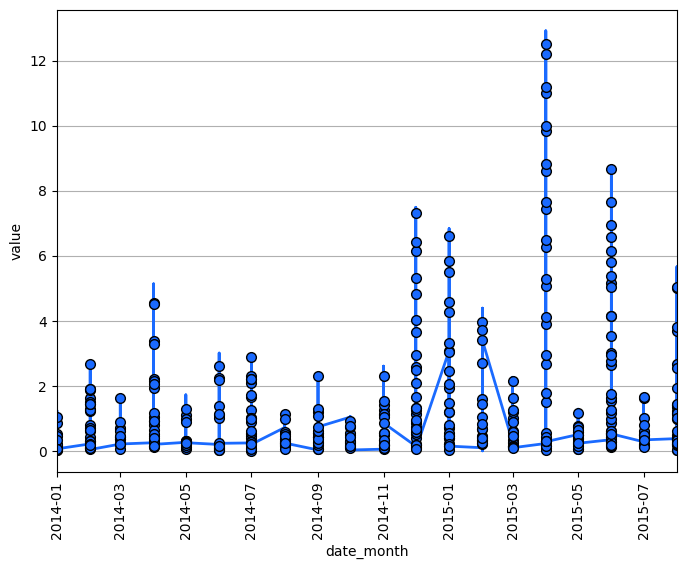

In [19]:
for i in [364, 399, 809, 951]:
    sm_consumption_month[sm_consumption_month["meterID"] == i]["value"].plot(ts = "date_month")

<b>Data Encoding & Bivariate Analysis</b>

Since most of our data is categorical, let's encode them with One-hot encoding. We can then examine the correlations between the various categories.

,123meterIDInteger,123regionInteger,123residenceTypeInteger,📅dateUTCTimestamp(29),123monthInteger,📅date_monthTimestamp(29),123valueFloat(22),123avg_temperatureFloat(22),123avg_humidityFloat(22),123value_zscoreFloat(22),123region_0Integer,123region_1Integer,123region_2Integer,123region_3Integer,123region_4Integer,123residenceType_1Integer,123residenceType_2Integer,123residenceType_3Integer,123month_1Integer,123month_2Integer,123month_3Integer,123month_4Integer,123month_5Integer,123month_6Integer,123month_7Integer,123month_8Integer,123month_9Integer,123month_10Integer,123month_11Integer,123month_12Integer
1,0,4,1,2014-01-01 11:00:00,1,2014-01-01 00:00:00,0.029,37.4,87.0,-0.511299880583975,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,0,4,1,2014-01-01 11:30:00,1,2014-01-01 00:00:00,0.0740909090909091,37.7272727272727,87.0,-0.438768053641264,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,4,1,2014-01-01 12:00:00,1,2014-01-01 00:00:00,0.119181818181818,38.0545454545455,87.0,-0.366236226698554,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,0,4,1,2014-01-01 12:30:00,1,2014-01-01 00:00:00,0.164272727272727,38.3818181818182,87.0,-0.293704399755844,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
5,0,4,1,2014-01-01 13:00:00,1,2014-01-01 00:00:00,0.209363636363636,38.7090909090909,87.0,-0.221172572813133,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
6,0,4,1,2014-01-01 13:30:00,1,2014-01-01 00:00:00,0.254454545454545,39.0363636363636,87.0,-0.148640745870423,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
7,0,4,1,2014-01-01 14:00:00,1,2014-01-01 00:00:00,0.27752380952381,39.2214285714286,86.7976190476191,-0.111532248771949,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
8,0,4,1,2014-01-01 14:30:00,1,2014-01-01 00:00:00,0.278571428571429,39.2642857142857,86.3928571428571,-0.109847081517712,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
9,0,4,1,2014-01-01 15:00:00,1,2014-01-01 00:00:00,0.279619047619048,39.3071428571429,85.9880952380952,-0.108161914263474,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
10,0,4,1,2014-01-01 15:30:00,1,2014-01-01 00:00:00,0.280666666666667,39.35,85.5833333333333,-0.106476747009237,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0

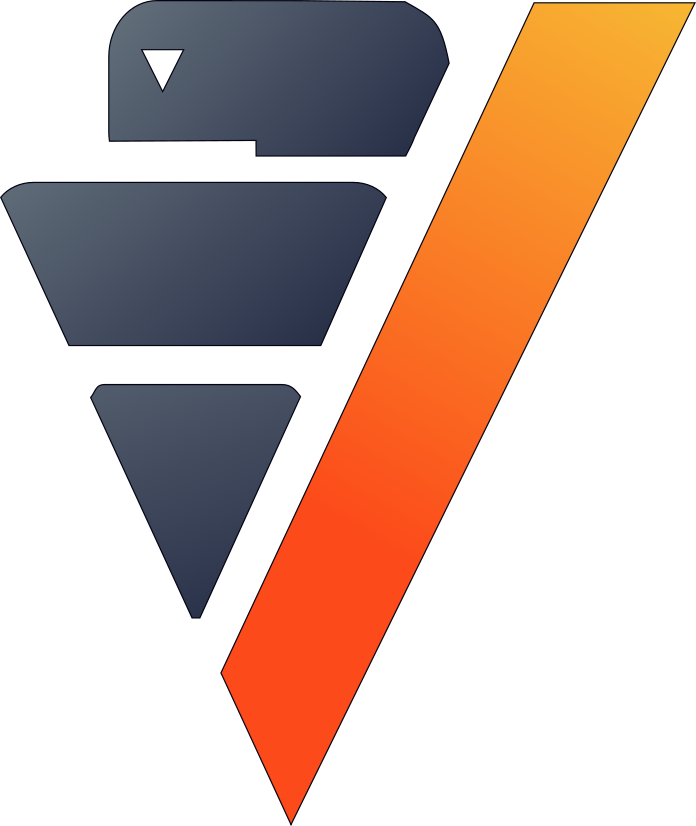

In [20]:
sm_consumption_month = sm_consumption_month.one_hot_encode(["region", "residenceType", "month"], 
                                                           drop_first = False,
                                                           max_cardinality = 20)
display(sm_consumption_month)

Let's compute the Pearson correlation matrix.

<Axes: >

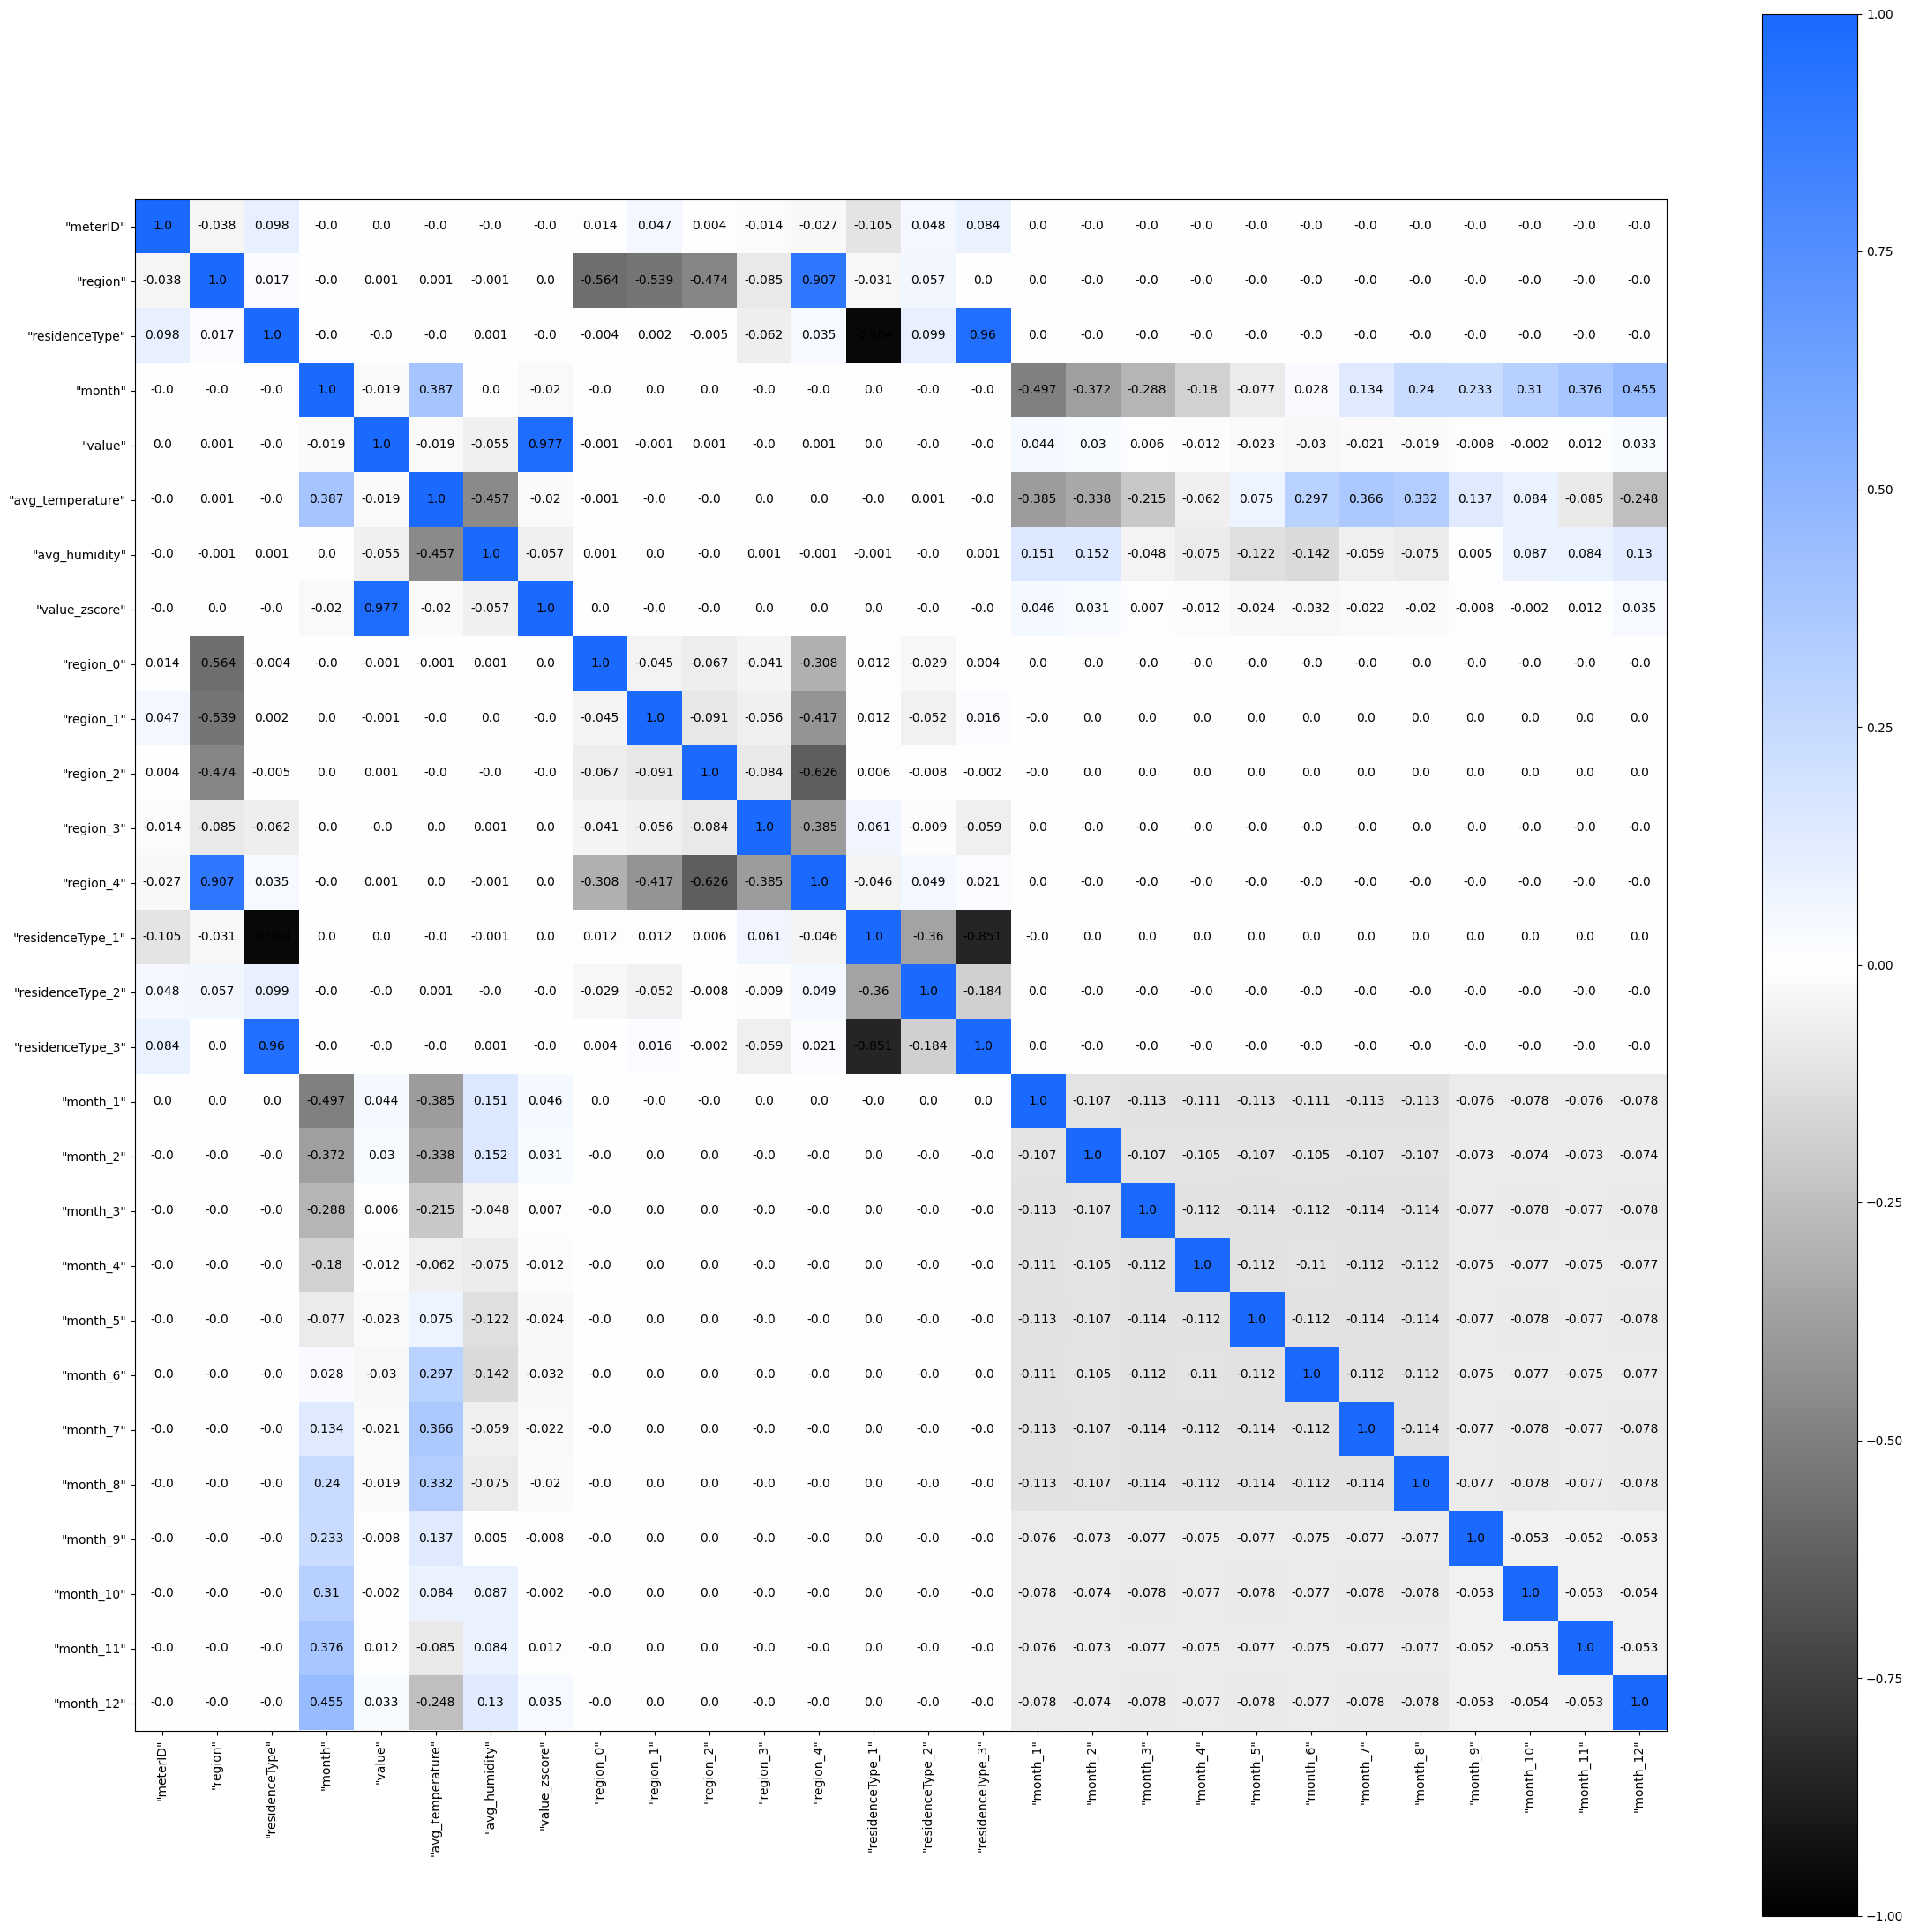

In [21]:
sm_consumption_month.corr()

There's a clear correlation between the month and energy consumption, but this isn't causal. Instead, we can think of the weather as having the direct influence on energy consumption. To accomodate for this view, we'll use the temperature as a predictor (rather than the month).

<Axes: >

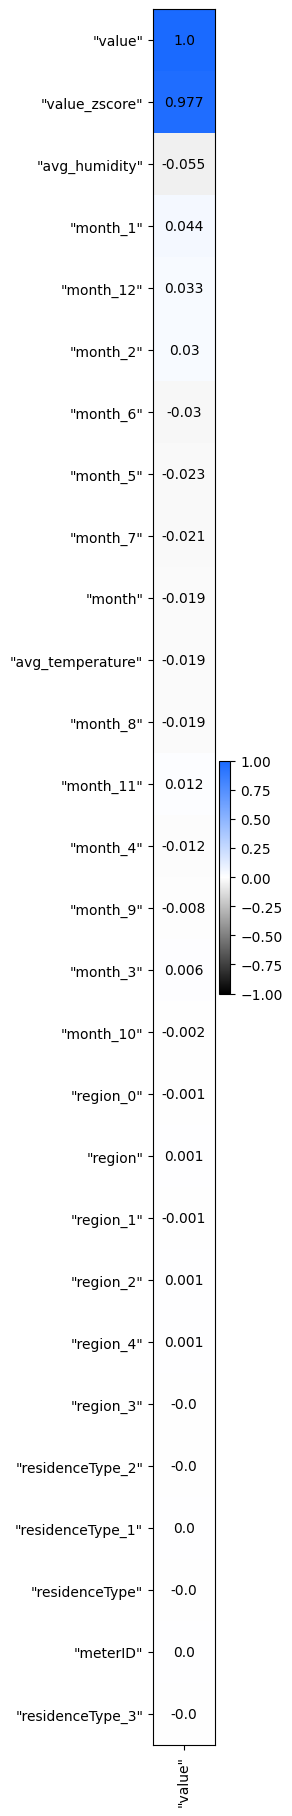

In [22]:
sm_consumption_month.corr(focus = "value")

<b>Global Behavior</b>

Let's look at this globally.

<Axes: xlabel='date_month'>

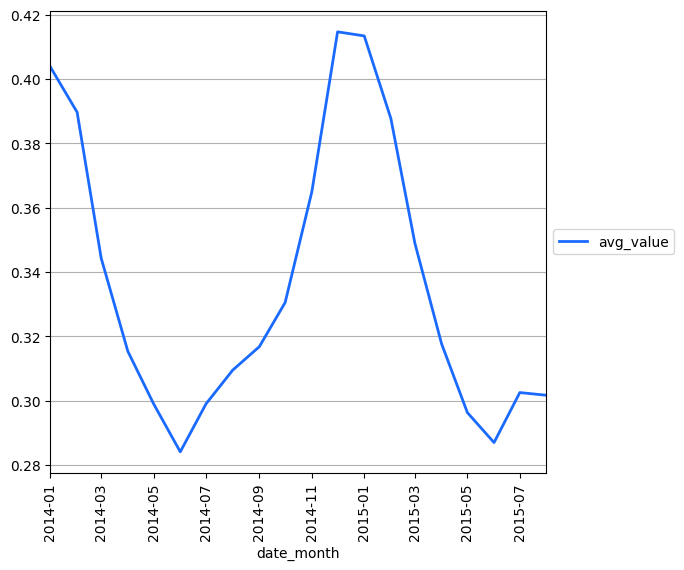

In [23]:
sm_consumption_final = sm_consumption_month.groupby(
                            ["date_month"], 
                            [st.avg(sm_consumption_month["avg_temperature"])._as("avg_temperature"),
                             st.avg(sm_consumption_month["avg_humidity"])._as("avg_humidity"),
                             st.avg(sm_consumption_month["value"])._as("avg_value")])
sm_consumption_final.plot(ts = "date_month", columns = ["avg_value"])

We expect to see a fall in energy consumption during summer and then an increase during the winter. A simple prediction could use the average value a year before.

0.99422260697163

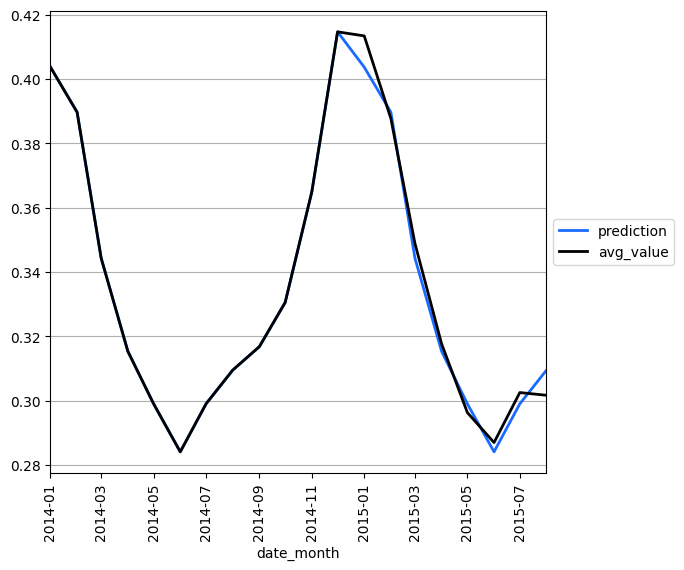

In [24]:
sm_consumption_final["prediction"] = st.case_when(sm_consumption_final["date_month"] < '2015-01-01', 
                                                  sm_consumption_final["avg_value"],
                                                  st.lag(sm_consumption_final["avg_value"], 12)._over(
                                                                                order_by = ["date_month"]))
sm_consumption_final.plot(ts = "date_month", columns = ["prediction", "avg_value"])
sm_consumption_final.score("avg_value", "prediction", "r2")

As expected, our model's score is excellent.

Let's use machine learning to understand the influence of the weather and the humidity on energy consumption.

## Machine Learning

Let's create our model.



details
   predictor   |coefficient|std_err |t_value |p_value 
---------------+-----------+--------+--------+--------
   Intercept   |  0.09059  | 0.11593| 0.78143| 0.44529
avg_temperature| -0.00313  | 0.00058|-5.43513| 0.00004
 avg_humidity  |  0.00474  | 0.00113| 4.20872| 0.00059


regularization
type| lambda 
----+--------
none| 1.00000


call_string
linear_reg('public.sm_lr', '"public"."_verticapy_tmp_view_v_demo_81a48facc10011ee8de90242ac120003_"', '"avg_value"', '"avg_temperature", "avg_humidity"'
USING PARAMETERS optimizer='bfgs', epsilon=1e-06, max_iterations=100, regularization='none', lambda=1, alpha=0.5, fit_intercept=true)

Additional Info
       Name       |Value
------------------+-----
 iteration_count  |  4  
rejected_row_count|  0  
accepted_row_count| 20  



,value
Dep. Variable,"""avg_value"""
Model,LinearRegression
No. Observations,20.0
No. Predictors,2
R-squared,0.898083544501315
Adj. R-squared,0.8860933732661755
F-statistic,74.90164460615877
Prob (F-statistic),5.138530880054037e-10
Kurtosis,-1.00259592898878
Skewness,0.684153387078271

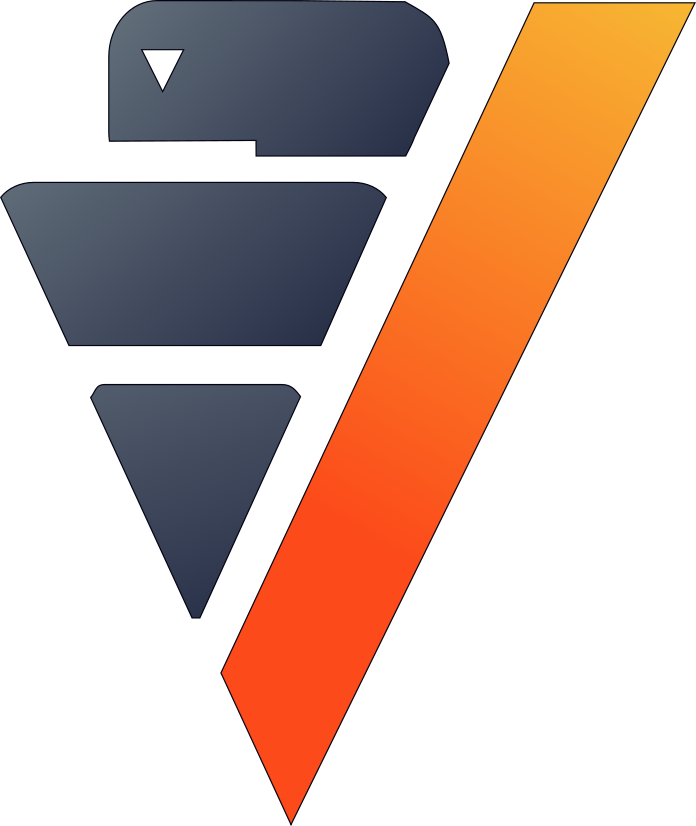

In [25]:
from verticapy.machine_learning.vertica.linear_model import LinearRegression

predictors = ["avg_temperature",
              "avg_humidity"]
model = LinearRegression("sm_lr", solver = "BFGS")
model.fit(sm_consumption_final, 
          predictors,
          "avg_value")
model.report("details")

The model seems to be good with an adjusted R2 of 77.5%, and the F-Statistic indicates that at least one of the two predictors is useful. Let's look at the residual plot.

<Axes: xlabel='avg_value', ylabel='residual'>

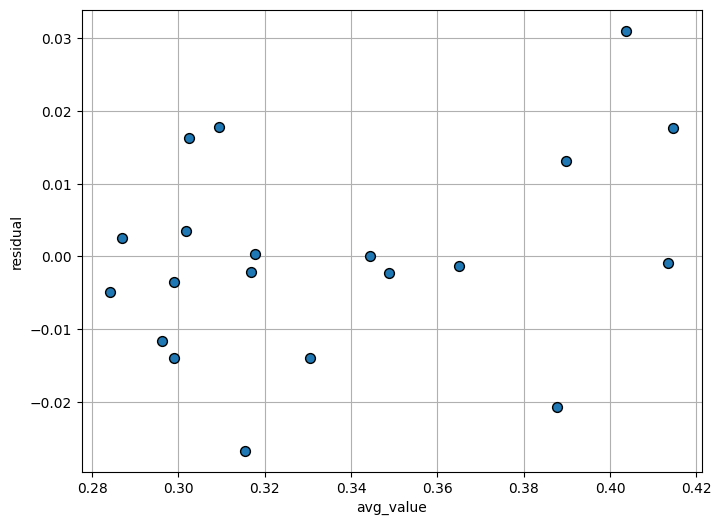

In [26]:
sm_consumption_final = model.predict(sm_consumption_final, 
                                     name = "value_prediction")
sm_consumption_final["residual"] = sm_consumption_final["avg_value"] - sm_consumption_final["value_prediction"]
sm_consumption_final.scatter(["avg_value", "residual"])

Looking at the residual plot, we can see that the error variance varies by quite a bit. A possible suspect might be heteroscedasticity. Let's verify our hypothesis using a Breusch-Pagan test.

In [27]:
from verticapy.machine_learning.model_selection.statistical_tests import het_breuschpagan

het_breuschpagan(sm_consumption_final, "residual", predictors)

(1.6262892128726918,
 0.4434613598814614,
 0.7523498366537177,
 0.48631591598485446)

The p-value is 4.81% and sits around the 5% threshold, so we can't really draw any conclusions.

Let's look at the entire regression report.

,value
explained_variance,0.898083544501315
max_error,0.031069669825538
median_absolute_error,0.00828823772626949
mean_absolute_error,0.0102153948155827
mean_squared_error,0.000188317963380062
root_mean_squared_error,0.0137228992337648
r2,0.898083544501315
r2_adj,0.886093373266176
aic,-162.922574583752
bic,-162.56037776309

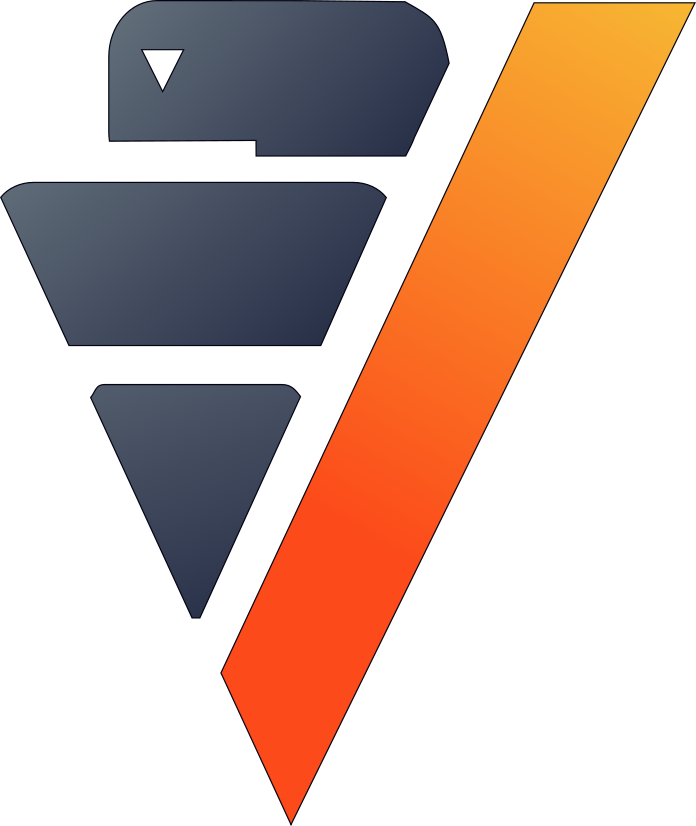

In [28]:
model.report()

Our model is very good; its median absolute error is around 13kWh. 

With this model, we can make predictions about the energy consumption of households per region. If the usage exceeds what the model predicts, we can raise an alert and respond, for example, by regulating the electricity distributed to the region.

## Conclusion

We've solved our problem in a Pandas-like way, all without ever loading data into memory!